In [1]:
import matplotlib
matplotlib.use("Agg")
import plotly.io as pio
pio.renderers.default = "png"

# Regression

The regression helpers turn a fitted [statsmodels](https://www.statsmodels.org)
model into tidy polars tables — the analog of R `moderndive`'s
`get_regression_table()` / `get_regression_points()` / `get_regression_summaries()`.

Fit models with statsmodels' formula API, then tidy them:

In [2]:
import statsmodels.formula.api as smf
import moderndive as md
from moderndive import (
    get_regression_table, get_regression_points, get_regression_summaries, get_correlation,
)

houses = md.load_saratoga_houses()
model = smf.ols("price ~ living_area + bedrooms", data=houses.to_pandas()).fit()

## Coefficient table (with confidence intervals)

In [3]:
get_regression_table(model)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
str,f64,f64,f64,f64,f64,f64
"""intercept""",20986.094,6816.251,3.079,0.002,7611.128,34361.06
"""living_area""",93.842,3.109,30.183,0.0,87.741,99.943
"""bedrooms""",-7483.095,2783.531,-2.688,0.007,-12944.988,-2021.203


Change the confidence level with `conf_level=` (e.g. `0.99`).

## Fitted values & residuals

In [4]:
get_regression_points(model).head()
# columns: ID, price, living_area, bedrooms, price_hat, residual

ID,price,living_area,bedrooms,price_hat,residual
i64,i64,i64,i64,f64,f64
1,142212,1982,3,184531.942,-42319.942
2,134865,1676,3,155816.245,-20951.245
3,118007,1694,3,157505.404,-39498.404
4,138297,1800,2,174935.767,-36638.767
5,129470,2088,3,194479.21,-65009.21


## Model-fit summaries

In [5]:
get_regression_summaries(model)
# r_squared, adj_r_squared, mse, rmse, sigma, statistic (F), p_value, df, nobs

r_squared,adj_r_squared,mse,rmse,sigma,statistic,p_value,df,nobs
f64,f64,f64,f64,f64,f64,f64,i64,i64
0.578,0.578,2.5071e9,50071.187,50142.395,723.229,0.0,2,1057


## Correlation

In [6]:
get_correlation(houses, "price ~ living_area")   # ≈ 0.759
# or: get_correlation(houses, x="living_area", y="price")

cor
f64
0.758674


## Visualizing models

Two ports of R `moderndive`'s ggplot helpers, both dual-engine:

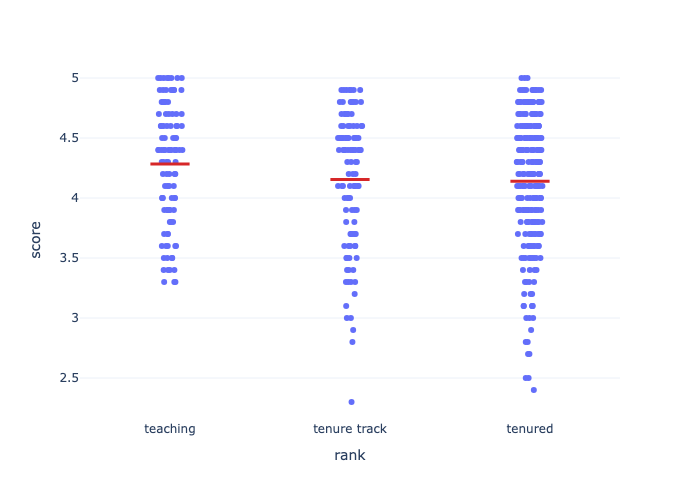

In [7]:
from moderndive import gg_parallel_slopes, gg_categorical_model

evals = md.load_evals()

# Parallel-slopes model: one common slope, a separate intercept per group
gg_parallel_slopes(evals, response="score", explanatory="age", by="gender")            # plotly
gg_parallel_slopes(evals, response="score", explanatory="age", by="gender",
                   engine="plotnine")

# Regression with a single categorical predictor
gg_categorical_model(evals, response="score", explanatory="rank")

For the plotnine engine you can also drop the parallel-slopes lines onto your own
`ggplot` with `geom_parallel_slopes()`.

## Inference for regression coefficients

`fit()` runs the regression on every bootstrap/permutation replicate, giving a
distribution per coefficient. Pair it with `visualize_fit` and **per-facet**
shading:

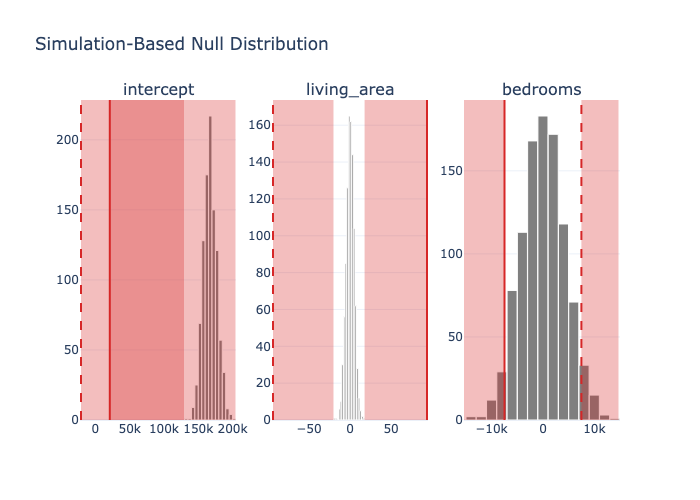

In [8]:
from moderndive import specify
from moderndive.infer.viz import visualize_fit
from moderndive import shade_confidence_interval, shade_p_value

f = "price ~ living_area + bedrooms"
obs_fit = specify(houses, formula=f).fit()

# Bootstrap distribution of each coefficient → per-term CIs
boot_fit = specify(houses, formula=f).generate(reps=1000, type="bootstrap", seed=1).fit()
boot_fit.get_confidence_interval(level=0.95)          # one row per term
visualize_fit(boot_fit) + shade_confidence_interval(boot_fit.get_confidence_interval())

# Null distribution → per-term p-values, each facet shaded at its own estimate
null_fit = (
    specify(houses, formula=f).hypothesize(null="independence")
    .generate(reps=1000, type="permute", seed=1).fit()
)
null_fit.get_p_value(obs_stat=obs_fit, direction="two-sided")
visualize_fit(null_fit) + shade_p_value(obs_stat=obs_fit, direction="two-sided")

Per-facet shading works in both engines: `shade_p_value` / `shade_confidence_interval`
accept the observed `FitResult` or a term-keyed table, and each facet is shaded
from its own value.